In [45]:
import sys

import numpy as np
from scipy.signal import find_peaks
from scipy.optimize import curve_fit
from astropy.io import fits
import matplotlib.pyplot as plt
import matplotlib as mpl

from find_spectra import load_data, save_data, find_spectra, extract_spectra, check_data_orientation

In [7]:
# data = load_data('../data/datacube.fits')
# data = load_data('/import/morgana2/snert/GLINT/sample_data/spectral_extraction/nd2/ideal.fits',
#                  dark_filepath='/import/morgana2/snert/GLINT/sample_data/spectral_extraction/nd2/dark.fits')
data = load_data('../data/rotated/bright.fits',
                 dark_filepath='../data/rotated/dark.fits')

if data != check_data_orientation(data):
    print('Rotating data')
    data = check_data_orientation(data)
print(data.shape)

Rotating data
(1, 314, 250)


/usr/physics/python/anaconda3-201907/lib/python3.7/site-packages/ipykernel_launcher.py:7: DeprecationWarning: elementwise comparison failed; this will raise an error in the future.
  import sys


In [8]:
peaks, box_top, box_bottom = find_spectra(data[0])
print('Peaks:', peaks)
print(f'Box range: [{box_top}, {box_bottom}]')

Peaks: [  6  26  45  64  83 102 121 140 160 198 217 237]
Box range: [9, 223]


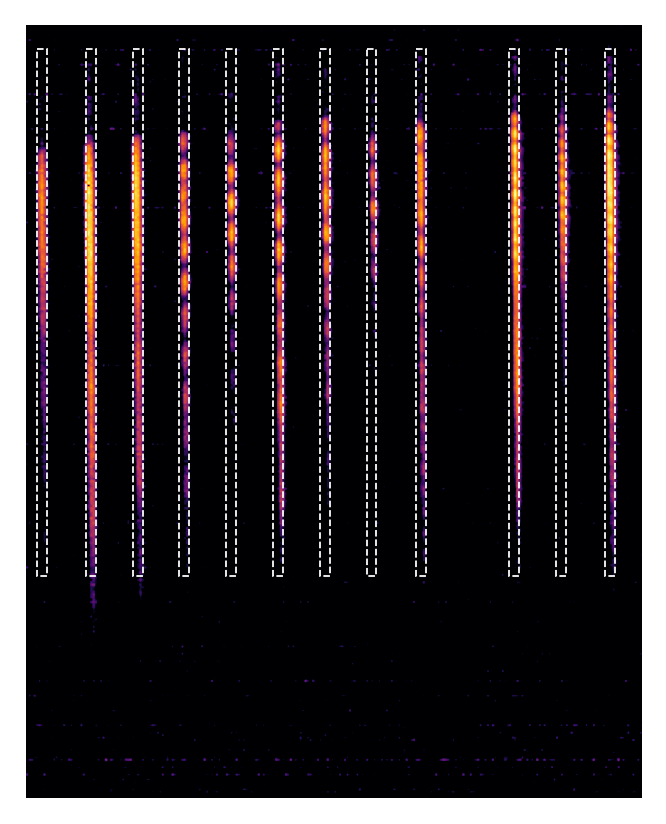

In [5]:
plt.figure(dpi=256, facecolor='w')
plt.imshow(data[-1], norm=mpl.colors.LogNorm(vmin=100), cmap='inferno')

box_half_width = 2
for peak in peaks:
    box = mpl.patches.Rectangle((peak-box_half_width, box_top), 2*box_half_width, 
                                box_bottom-box_top, ls='--', color='w', fill=False, lw=0.5)
    plt.gca().add_patch(box)

plt.axis('off')
plt.show()

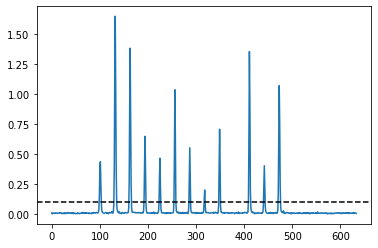

In [11]:
# Rescale data
x_axis = data[0].mean(axis=0)

x_axis = x_axis - np.percentile(x_axis, 1)
x_axis = x_axis / np.percentile(x_axis, 99)

plt.plot(x_axis)
plt.axhline(0.1, color='k', ls='--');


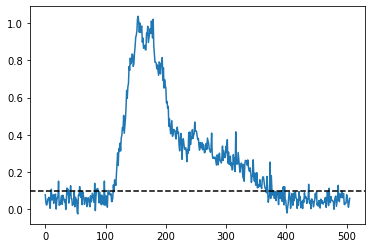

In [12]:
# Rescale data
y_axis = data[0].mean(axis=1)

y_axis = y_axis - np.percentile(y_axis, 1)
y_axis = y_axis / np.percentile(y_axis, 99)

plt.plot(y_axis)
plt.axhline(0.1, color='k', ls='--');

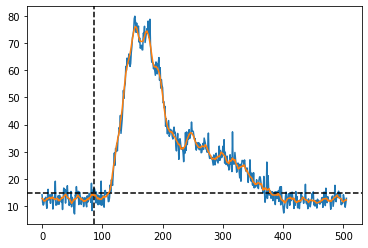

In [12]:
y_axis = np.mean(data[0], axis=1)

plt.plot(y_axis)

# Take moving average to smooth out noise
half_window = 5
y_axis = np.pad(y_axis, half_window, mode='edge')
cum_sum = np.cumsum(y_axis)
y_axis = (cum_sum[2*half_window:] - cum_sum[:-2*half_window])/(2*half_window)

baseline = np.median(y_axis[:10])
box_top = np.argmax(y_axis > 1.2*baseline) - 25

plt.axvline(box_top, color='k', ls='--')
plt.axhline(1.2*baseline, color='k', ls='--')

plt.plot(y_axis)

In [19]:
positive = (y_axis > 1.2*baseline)

idxs = np.flatnonzero(positive[:-1] != positive[1:])
idxs = np.hstack(([0], idxs, [len(positive)]))

sequence_lengths = idxs[1:]-idxs[:-1]
if positive[0]:
    sequence_lengths[1::2] *= -1
else:
    sequence_lengths[::2] *= -1

assert np.max(sequence_lengths) > 50, f'Very small sequence found: {np.max(sequence_lengths)}'
longest_indx = np.argmax(sequence_lengths)+1
longest_subseq = idxs[longest_indx-1:longest_indx+1]

print(longest_subseq)

[110 379]


In [288]:
# Rescale data
x_axis = data[0].mean(axis=0)
x_axis = x_axis - np.percentile(x_axis, 1)
x_axis = x_axis / np.percentile(x_axis, 99)

# Find peaks
height = 0.1
peaks = find_peaks(x_axis, height=height, distance=25)[0]

# Retry peak finding until successful
if len(peaks) != 12:
    min_height = -0.05
    max_height = 1.
    while len(peaks) != 12:
        if len(peaks) < 12:
            max_height = height
        else:
            min_height = height

        height = (min_height + max_height)/2
#         print(f'Trying {height:.2f}')
        peaks = find_peaks(x_axis, height=height, distance=25)[0]

# Check peaks are valid
peak_offsets = peaks[1:] - peaks[:-1]
assert peak_offsets.min() > 27, f'Bad peaks (too close): {peaks}'
assert peak_offsets.max() < 66, f'Bad peaks (too far): {peaks}'

# Find box locations
y_axis = np.mean(data, axis=1)

# Take moving average to smooth out noise
half_window = 5
y_axis = np.pad(y_axis, half_window, mode='edge')
cum_sum = np.cumsum(y_axis)
y_axis = (cum_sum[2*half_window:] - cum_sum[:-2*half_window])/(2*half_window)

baseline = np.median(y_axis[:10])
box_top = np.argmax(y_axis > 1.2*baseline) - 25

## Loading data

Rotating data
Peaks: [  6  26  45  64  83 102 121 140 160 198 217 237]
Box range: [9, 223]


/usr/physics/python/anaconda3-201907/lib/python3.7/site-packages/ipykernel_launcher.py:4: DeprecationWarning: elementwise comparison failed; this will raise an error in the future.
  after removing the cwd from sys.path.


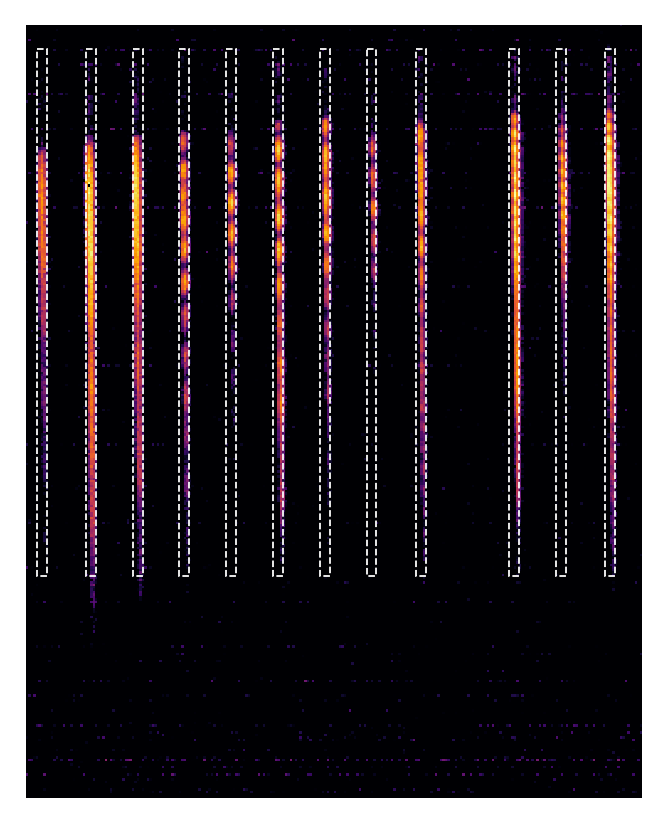

In [30]:
data = load_data('../data/rotated/bright.fits',
                 dark_filepath='../data/rotated/dark.fits')

if data != check_data_orientation(data):
    print('Rotating data')
    data = check_data_orientation(data)
    
peaks, box_top, box_bottom = find_spectra(data[0])
print('Peaks:', peaks)
print(f'Box range: [{box_top}, {box_bottom}]')

plt.figure(dpi=256, facecolor='w')
plt.imshow(data[-1], norm=mpl.colors.LogNorm(vmin=100), cmap='inferno', interpolation='none')

box_half_width = 2
for peak in peaks:
    box = mpl.patches.Rectangle((peak-box_half_width, box_top), 2*box_half_width, 
                                box_bottom-box_top, ls='--', color='w', fill=False, lw=0.5)
    plt.gca().add_patch(box)

plt.axis('off')
plt.show()

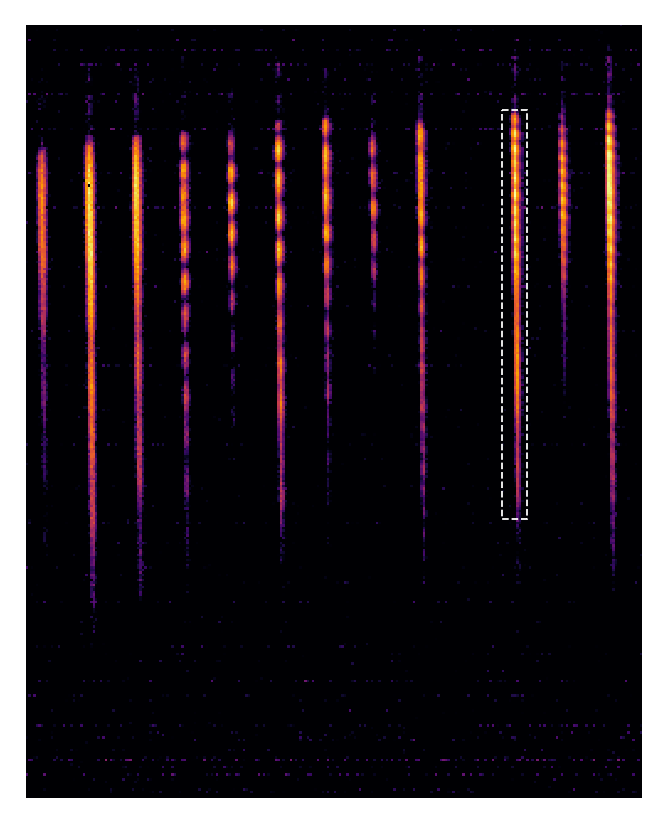

In [84]:
plt.figure(dpi=256, facecolor='w')
plt.imshow(data[-1], norm=mpl.colors.LogNorm(vmin=100), cmap='inferno', interpolation='none')

box_half_width = 2
box_bottom = 175
for peak in peaks[-3:-2]:
    box = mpl.patches.Rectangle((peak-5, 34), 2*5, 
                                box_bottom-box_top, ls='--', color='w', fill=False, lw=0.5)
    plt.gca().add_patch(box)

plt.axis('off')
plt.show()

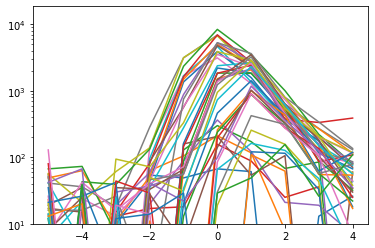

In [77]:
spectrum = data[:, box_top:box_bottom, peaks[-3]-5:peaks[-3]+5]
spectrum = spectrum.sum(axis=0)

# spectrum = spectrum / spectrum.mean(axis=1).reshape(-1, 1)

plt.plot(np.arange(-5, +5), spectrum[::5].T)
plt.yscale('log')
plt.ylim(bottom=10.);

In [44]:
def gaussian(x, a, b, c):
    return a*np.exp(-(x-b)**2/(2*c**2))

[1.82368941e+03 5.00369618e-01 7.91474205e-01]


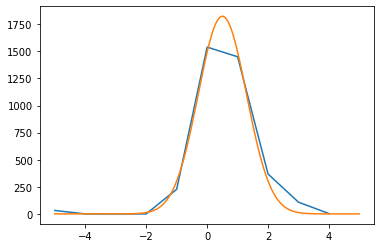

In [57]:
x_range = np.arange(-5, 5)
dense_x = np.arange(-5, 5, 0.01)
params, _ = curve_fit(gaussian, np.arange(-5, +5), spectrum[78])
print(params)
plt.plot(x_range, spectrum[78].T)
plt.plot(dense_x, gaussian(dense_x, *params));

In [62]:
round(params[1]-2.5), round(params[1]+2.5)

(-2.0, 3.0)

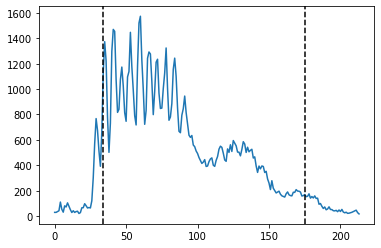

In [85]:
plt.plot(spectrum.mean(axis=1))
plt.axvline(34, color='k', ls='--')
plt.axvline(175, color='k', ls='--')